In [205]:
import ee
ee.Authenticate(force=True)
ee.Initialize(project='amelia-lies')


Successfully saved authorization token.


In [ ]:
from __future__ import annotations
import json
import math
import os
import random
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import ee
import geemap
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import Polygon, mapping

def init_ee():
    try:
        ee.Initialize()
    except Exception:
        ee.Authenticate()
        ee.Initialize()
init_ee()

# Alaska ROI
ALASKA = (ee.FeatureCollection("TIGER/2018/States").filter(ee.Filter.eq("NAME", "Alaska")))
ROI = ALASKA.geometry()

### Alaska Wildland Fire and Lightning Dashboard
https://nifc.maps.arcgis.com/apps/dashboards/7549e69563894b8ebf4a8d138c5424e0


# In which months do most fires occur?

In [ ]:
def monthly_fire_counts(years, roi):
    col = (
        ee.ImageCollection("MODIS/061/MCD64A1")
        .filterBounds(roi)
        .filter(ee.Filter.calendarRange(min(years), max(years), "year"))
        .select("BurnDate"))
    months = ee.List.sequence(1, 12)
    
    def compute_month(m):
        m = ee.Number(m)
        def per_image(img):
            burn = img.gt(0)
            date = ee.Date(img.get("system:time_start")) # máscara de mes
            month = date.get("month")
            return burn.updateMask(ee.Number(month).eq(m))
        
        monthly_imgs = col.map(per_image)
        total = monthly_imgs.sum().reduceRegion(reducer= ee.Reducer.sum(), geometry=roi, scale=500, maxPixels=1e13
        ).get("BurnDate")
        
        return ee.Feature(None, {"month": m,"burned_pixels": total})
    
    return ee.FeatureCollection(months.map(compute_month))

monthly = monthly_fire_counts(list(range(2000, 2025)), ROI)
months = monthly.aggregate_array("month").getInfo()
counts = monthly.aggregate_array("burned_pixels").getInfo()
df = pd.DataFrame({"month": months, "burned": counts})

    month         burned
0       1       0.000000
1       2       0.000000
2       3      42.000000
3       4     369.000000
4       5   13199.352941
5       6  268094.686275
6       7  288197.972549
7       8  284793.298039
8       9   27618.168627
9      10      61.000000
10     11       0.000000
11     12       0.000000


In [ ]:
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
df["month_name"] = df["month"].map(month_names)
df = df.sort_values("month")

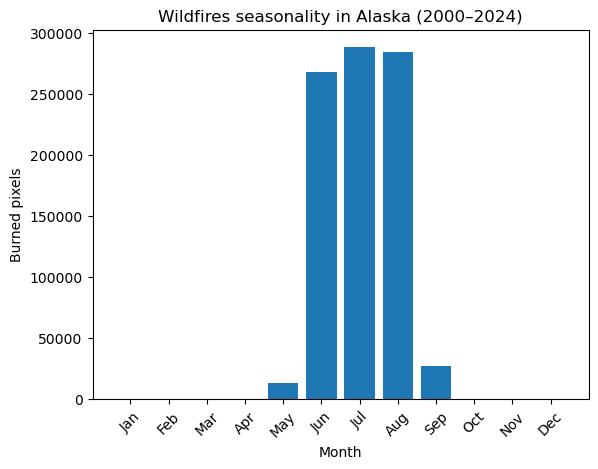

In [ ]:
plt.figure()
plt.bar(df["month_name"], df["burned"])
plt.xlabel("Month")
plt.ylabel("Burned pixels")
plt.title("Wildfires seasonality in Alaska (2000–2024)")
plt.xticks(rotation=45)
plt.show()

Since wildfires are concentrated in June–August, the model does not need to learn across the full annual cycle -> temporal negatives can be sampled within the same month or week across different years

# Space frequency of wildfires in Alaska Grid (2002-2025)

This analysis helps highlight regions with recurrent fire activity, providing insight into spatial patterns of wildfire occurrence

In [1]:
import ee
import geemap

ee.Initialize()

ALASKA = (ee.FeatureCollection("TIGER/2018/States").filter(ee.Filter.eq("NAME", "Alaska")))
ROI = ALASKA.geometry()
MODIS_BURN = "MODIS/061/MCD64A1"

def annual_burn(year):
    burn = (ee.ImageCollection(MODIS_BURN)
        .filterBounds(ROI)
        .filterDate(f"{year}-01-01", f"{year+1}-01-01").select("BurnDate").max().gt(0))
    return burn.rename("burn")

def fire_frequency(years):
    imgs = [annual_burn(y) for y in years]
    return ee.ImageCollection(imgs).sum().rename("freq")

def make_grid(cell_km=50):
    proj = ee.Projection("EPSG:3338")
    cell_m = cell_km * 1000

    bounds = ROI.transform(proj, 1).bounds(1, proj)
    coords = bounds.coordinates().getInfo()[0]

    xs = [p[0] for p in coords]
    ys = [p[1] for p in coords]
    xmin, xmax = min(xs), max(xs)
    ymin, ymax = min(ys), max(ys)

    feats = []
    idx = 0
    y = ymin
    while y < ymax:
        x = xmin
        while x < xmax:
            geom = ee.Geometry.Rectangle(
                [x, y, x+cell_m, y+cell_m],
                proj=proj,
                geodesic=False)
            feats.append(ee.Feature(geom, {"cell_id": idx}))
            idx += 1
            x += cell_m
        y += cell_m
    return ee.FeatureCollection(feats).filterBounds(ROI)


def aggregate_to_grid(freq_img, grid):
    return freq_img.reduceRegions(
        collection=grid,
        reducer=ee.Reducer.mean().combine(ee.Reducer.max(), "", True).combine(ee.Reducer.sum(), "", True),
        scale=500,
        tileScale=4)

years = list(range(2002, 2025))
freq_img = fire_frequency(years)
grid = make_grid(25)
grid_stats = aggregate_to_grid(freq_img, grid)


/opt/anaconda3/envs/geo_ai/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


- Yearly wildfire occurrence was approximated using the MODIS burned area product
- To enable spatial analysis at a coarser and more interpretable scale, a regular grid (25 km resolution) was constructed, but pixel-level analysis was included

In [2]:
# SUM FREQUENCY OF WILDFIRES
grid_img = grid_stats.reduceToImage(
    properties=["sum"], reducer=ee.Reducer.first())

max_val = grid_img.reduceRegion(
    reducer=ee.Reducer.max(),
    geometry=ROI,
    scale=500,
    bestEffort=True).get("first")

- Computed sum to get accumulated burned pixels over time within a grid cell

In [ ]:
Map = geemap.Map()
Map.centerObject(ROI, 4)
Map.addLayer(
    grid_img,
    {
        "min": 0,
        "max": max_val.getInfo(),
        "palette": ["white", "yellow", "orange", "red"]},
    "Fire frequency (grid mean)")
Map.addLayer(grid.style(**{"color": "gray", "fillColor": "00000000"}),{},"Grid")
Map.addLayer(
    freq_img,
    {
        "min": 0,
        "max": 5,
        "palette": ["white", "yellow", "orange", "red", "darkred"]}, 
    "Fire frequency (pixel)")
Map

Map(center=[63.42264597216145, -152.81282767956722], controls=(WidgetControl(options=['position', 'transparent…

- Based on the identified hotspots, polygons were manually delineated over regions with high wildfire activity to define the initial Regions of Interest (ROIs) for this project

Save manually marked polygons:

In [5]:
hotspot_areas = Map.draw_features
geoms = [f.geometry() for f in hotspot_areas]

In [ ]:
fc = ee.FeatureCollection([ee.Feature(g) for g in geoms])
geemap.ee_export_vector(fc, filename='hotspots1.geojson')

Generating URL ...
Please wait ...
Data downloaded to /Users/amelia/Library/CloudStorage/OneDrive-Personal/GSoC2026/hotspots.geojson


Import polygons:

In [7]:
fc = geemap.geojson_to_ee('hotspots.geojson')
ROI = fc.geometry()

In [ ]:
# Calculate total area
ROI = fc.geometry(1) 
area_m2 = ROI.area(1)  
area_km2 = area_m2.divide(1e6)
print("Área total (km²):", area_km2.getInfo())

Área total (km²): 17104.65251235085


In [ ]:
Map = geemap.Map()
Map.centerObject(ROI, 5)
# NDVI 
ndvi = ee.ImageCollection("MODIS/061/MOD13Q1") \
    .select("NDVI") \
    .mean() \
    .multiply(0.0001) \
.clip(ROI)

Map.addLayer(ndvi, {"min": 0, "max": 1, "palette": ["white", "green"]}, "Vegetation (NDVI)")
# LST 
lst = ee.ImageCollection("MODIS/061/MOD11A2") \
    .select("LST_Day_1km") \
    .mean() \
    .multiply(0.02) \
    .subtract(273.15) \
    .clip(ROI)
    
Map.addLayer(lst, {"min": -10, "max": 30, "palette": ["blue", "yellow", "red"]}, "Land Surface Temperature (°C)")
# ROIs
Map.addLayer(fc, {"color": "blue"}, "ROIs")
# Fire frequency 
Map.addLayer(freq_img, {"min": 0, "max": 5, "palette": ["white", "yellow", "orange", "red", "darkred"]}, "Fire frequency (pixel)")
# Ecoregiones
ecoregions = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017")

# Filtrar solo Alaska
eco_ak = ecoregions.filterBounds(ALASKA)

# Visualizar
Map.addLayer(eco_ak, {}, "Ecoregions Alaska")
Map

Map(center=[65.96469750303329, -148.9948401169188], controls=(WidgetControl(options=['position', 'transparent_…

This visualization step ensures that the selected study regions and features are physically meaningful and ROIs are spread across differente ecoregions

In [9]:
# MEAN FREQUENCY OF WILDFIRES
grid_img = grid_stats.reduceToImage(
    properties=["mean"], reducer=ee.Reducer.first())

max_val = grid_img.reduceRegion(
    reducer=ee.Reducer.max(),
    geometry=ROI,
    scale=500,
    bestEffort=True).get("first")

Map = geemap.Map()
Map.centerObject(ROI, 4)
Map.addLayer(
    grid_img,
    {
        "min": 0,
        "max": max_val.getInfo(),
        "palette": ["white", "yellow", "orange", "red"]
    },
    "Fire frequency (grid mean)")
Map.addLayer(grid.style(**{"color": "gray", "fillColor": "00000000"}),{},"Grid")
Map.addLayer(
    freq_img,
    {
        "min": 0,
        "max": 5,
        "palette": ["white", "yellow", "orange", "red", "darkred"]
    }, "Fire frequency (pixel)")
Map

Map(center=[65.96469750303329, -148.99484011691877], controls=(WidgetControl(options=['position', 'transparent…

While the sum emphasizes total burned area, the mean captures how consistently fire occurs within a cell and reduces bias from large events. It acts as a secondary validation mechanism for ROI selection

In [ ]:
import ee
ECO = ee.FeatureCollection("RESOLVE/ECOREGIONS/2017")
eco_names = ECO.aggregate_array('ECO_NAME').distinct().sort()
nombres_lista = eco_names.getInfo()

print(f"Total de ecorregiones encontradas: {len(nombres_lista)}")
print("Ejemplos:", nombres_lista[:])

Total de ecorregiones encontradas: 847
Ejemplos: ['Adelie Land tundra', 'Admiralty Islands lowland rain forests', 'Aegean and Western Turkey sclerophyllous and mixed forests', 'Afghan Mountains semi-desert', 'Ahklun and Kilbuck Upland Tundra', 'Al-Hajar foothill xeric woodlands and shrublands', 'Al-Hajar montane woodlands and shrublands', 'Alai-Western Tian Shan steppe', 'Alashan Plateau semi-desert', 'Alaska Peninsula montane taiga', 'Alaska-St. Elias Range tundra', 'Albany thickets', 'Alberta-British Columbia foothills forests', 'Albertine Rift montane forests', 'Aldabra Island xeric scrub', 'Aleutian Islands tundra', 'Allegheny Highlands forests', 'Alps conifer and mixed forests', 'Altai alpine meadow and tundra', 'Altai montane forest and forest steppe', 'Altai steppe and semi-desert', 'Alto Paraná Atlantic forests', 'Amazon-Orinoco-Southern Caribbean mangroves', 'Amsterdam-Saint Paul Islands temperate grasslands', 'Amur meadow steppe', 'Anatolian conifer and deciduous mixed forest

# PIPELINE

In [ ]:
from __future__ import annotations
import json
import math
import os
import random
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import ee
import geemap
import geopandas as gpd
import numpy as np
import pandas as pd
from shapely.geometry import Polygon, mapping
def init_ee():
    try:
        ee.Initialize()
    except Exception:
        ee.Authenticate()
        ee.Initialize()
init_ee()

ROI_GEOJSON = "fairbanks.geojson"
ROI_GEOJSON = "hotspots.geojson"
GRID_CRS = "EPSG:3338"  
WGS84 = "EPSG:4326"
DEM = "COPERNICUS/DEM/GLO30"
MODIS_BURN = "MODIS/061/MCD64A1"
S2_SR = "COPERNICUS/S2_SR_HARMONIZED"
S1_GRD = "COPERNICUS/S1_GRD"
MODIS_LST = "MODIS/061/MOD11A2"
ERA5_LAND = "ECMWF/ERA5_LAND/HOURLY"
WORLD_COVER = "ESA/WorldCover/v100"
ALASKA_ALBERS = "EPSG:3338"

# Grid settings
NEGATIVE_NEIGHBOR_RINGS = 2
CELL_SIZE_M = 3000 # meters
SEQ_LEN = 24
STEP_DAYS = 7
PRED_HORIZON_DAYS = 30


# Sampling settings
FIRE_SEASON_START_MONTH = 5
FIRE_SEASON_END_MONTH = 8
NEG_NEAR_POSITIVE_BUFFER_CELLS = 1  
RANDOM_SEED = 42

# Analysis years
START_YEAR = 2002
END_YEAR = 2004


In [16]:
def load_roi_zones(geojson_path: str) -> gpd.GeoDataFrame:
    """Load a multi-zone ROI from GeoJSON in WGS84."""
    gdf = gpd.read_file(geojson_path)
    gdf["zone_id"] = np.arange(len(gdf), dtype=int)

    return gdf
roi_zone = load_roi_zones(ROI_GEOJSON)
roi_zone

,id,geometry,zone_id
0,0,"POLYGON ((-147.79907 65.32788, -147.0932 65.48...",0
1,1,"POLYGON ((-151.00708 66.23367, -150.58411 66.0...",1
2,2,"POLYGON ((-152.92694 65.79039, -152.6358 65.85...",2
3,3,"POLYGON ((-147.71668 64.68971, -147.7359 64.56...",3
4,4,"POLYGON ((-144.25598 65.66959, -144.25598 65.4...",4
5,5,"POLYGON ((-146.34888 64.03976, -146.53839 63.9...",5
6,6,"POLYGON ((-144.06097 66.41345, -144.24225 66.3...",6
7,7,"POLYGON ((-156.40137 65.17726, -156.85181 65.0...",7
8,8,"POLYGON ((-162.34772 68.41838, -162.52487 68.3...",8
9,9,"POLYGON ((-141.01502 69.22305, -140.90515 69.3...",9


### Generar malla fija sobre roi

In [ ]:
def build_global_grid(roi_zones, cell_size_m = CELL_SIZE_M):
    """
    Create a fixed grid 
    roi_zones: gpd.GeoDataFrame
    CELL_SIZE_M: int -> (meters)
    """
    roi_proj = roi_zones.to_crs(ALASKA_ALBERS)
    roi_union = roi_proj.geometry.unary_union

    minx, miny, maxx, maxy = roi_union.bounds

    # Snap bounds to grid
    minx = math.floor(minx / cell_size_m) * cell_size_m
    miny = math.floor(miny / cell_size_m) * cell_size_m
    maxx = math.ceil(maxx / cell_size_m) * cell_size_m
    maxy = math.ceil(maxy / cell_size_m) * cell_size_m

    rows = []
    cell_id = 0

    for r, y0 in enumerate(np.arange(miny, maxy, cell_size_m)):
        for c, x0 in enumerate(np.arange(minx, maxx, cell_size_m)):
            sq = Polygon([
                (x0, y0),
                (x0 + cell_size_m, y0),
                (x0 + cell_size_m, y0 + cell_size_m),
                (x0, y0 + cell_size_m)])

            centroid = sq.centroid

            if not roi_union.contains(centroid):
                continue

            rows.append({
                "cell_id": cell_id,
                "row": int(r),
                "col": int(c),
                "geometry": sq,   # 🔥 full geometry
                "centroid_x": centroid.x,
                "centroid_y": centroid.y,
                "cell_area_m2": sq.area,
            })

            cell_id += 1

    grid = gpd.GeoDataFrame(rows, geometry="geometry", crs=ALASKA_ALBERS)

    # Assign zone_id
    centroids = grid.copy()
    centroids["geometry"] = centroids.geometry.centroid
    zones_proj = roi_proj[["zone_id", "geometry"]].copy()
    joined = gpd.sjoin(centroids, zones_proj, how="left", predicate="within")
    zone_col = "zone_id_right" if "zone_id_right" in joined.columns else "zone_id"
    grid["zone_id"] = joined[zone_col].fillna(-1).astype(int)

    # Back to WGS84
    grid = grid.to_crs(WGS84)
    grid["centroid_lon"] = grid.geometry.centroid.x
    grid["centroid_lat"] = grid.geometry.centroid.y
    grid["cell_area_km2"] = grid["cell_area_m2"] / 1e6

    return grid
grid_gdf = build_global_grid(roi_zone, cell_size_m=CELL_SIZE_M)
grid_gdf.head()

,cell_id,row,col,geometry,centroid_x,centroid_y,cell_area_m2,zone_id,centroid_lon,centroid_lat,cell_area_km2
0,0,1,26,"POLYGON ((-159.42882 62.12961, -159.37132 62.1...",-280500.0,1363500.0,9000000.0,14,-159.402419,62.144076,9.0
1,1,1,27,"POLYGON ((-159.37132 62.13179, -159.31382 62.1...",-277500.0,1363500.0,9000000.0,14,-159.344890,62.146244,9.0
2,2,1,28,"POLYGON ((-159.31382 62.13395, -159.2563 62.13...",-274500.0,1363500.0,9000000.0,14,-159.287352,62.148390,9.0
3,3,1,29,"POLYGON ((-159.2563 62.13608, -159.19877 62.13...",-271500.0,1363500.0,9000000.0,14,-159.229807,62.150512,9.0
4,4,2,26,"POLYGON ((-159.43354 62.15635, -159.37599 62.1...",-280500.0,1366500.0,9000000.0,14,-159.407113,62.170817,9.0


In [ ]:
def gdf_to_ee_fc(gdf: gpd.GeoDataFrame) -> ee.FeatureCollection:
    feats = []
    for _, row in gdf.iterrows():
        props = row.drop(labels=["geometry"]).to_dict()
        geom = ee.Geometry(mapping(row.geometry))
        feats.append(ee.Feature(geom, props))
    return ee.FeatureCollection(feats)

grid_fc = gdf_to_ee_fc(grid_gdf)
roi = ee.FeatureCollection(grid_fc).geometry(1)

In [19]:
m = geemap.Map()
m.centerObject(roi, 8)
m.addLayer(grid_fc, {"color": "blue"}, "Grid")
m

Map(center=[65.96492359915477, -148.99682102726732], controls=(WidgetControl(options=['position', 'transparent…

## Fire catalog across years selected

In [20]:
def annual_burn_image(year, roi):
    col = (
        ee.ImageCollection(MODIS_BURN)
        .filterBounds(roi)
        .filterDate(f"{year}-01-01", f"{year + 1}-01-01")
        .select("BurnDate")
    )
    burn = ee.Image(ee.Algorithms.If(col.size().gt(0), col.max(), ee.Image.constant(0).rename("BurnDate")))
    return burn.clip(roi)

def annual_fire_polygons(year, roi, min_area_km2 = 5.0):
    burn_img = annual_burn_image(year, roi)
    burn_mask = burn_img.gt(0).selfMask()

    vectors = burn_mask.reduceToVectors(
        geometry=roi,
        scale=500,
        geometryType="polygon",
        eightConnected=True,
        labelProperty="burn",
        reducer=ee.Reducer.countEvery(),
        maxPixels=1e13,
        tileScale=4,
    )

    def _annotate(feat):
        geom = feat.geometry()
        stats = burn_img.reduceRegion(
            reducer=ee.Reducer.median(),
            geometry=geom,
            scale=500,
            bestEffort=True,
            maxPixels=1e13,
            tileScale=4,
        )
        burn_day = ee.Number(ee.Algorithms.If(stats.get("BurnDate"), stats.get("BurnDate"), 0))
        area_km2 = geom.area(1).divide(1e6)
        centroid = geom.centroid(1).coordinates()
        lon = ee.Number(centroid.get(0))
        lat = ee.Number(centroid.get(1))
        fire_date = ee.Date.fromYMD(year, 1, 1).advance(burn_day.subtract(1), "day")
        return ee.Feature(geom).set(
            {
                "fire_year": year,
                "burn_day": burn_day,
                "fire_date": fire_date.format("YYYY-MM-dd"),
                "area_km2": area_km2,
                "centroid_lon": lon,
                "centroid_lat": lat,
            }
        )

    annotated = vectors.map(_annotate)
    return annotated.filter(ee.Filter.gt("area_km2", min_area_km2)).filter(ee.Filter.gt("burn_day", 0))

def build_fire_catalog(years, roi, min_area_km2=5.0):
    '''
    year: int
    roi: ee.Geometry
    min_area_km2: float
    '''
    merged = ee.FeatureCollection([])
    for y in years:
        yearly = annual_fire_polygons(y, roi, min_area_km2=min_area_km2)
        merged = merged.merge(yearly)
    return merged
years = list(range(START_YEAR, END_YEAR + 1))
fire_fc = build_fire_catalog(years, roi, min_area_km2=5.0)

print("N fires:", fire_fc.size().getInfo())

N fires: 24


In [ ]:
def ee_fc_to_df(fc: ee.FeatureCollection) -> pd.DataFrame:
    return geemap.ee_to_df(fc)

def positive_cells_for_fire_event(fire_feat, grid_fc, min_cell_overlap=0.0):
    """
    Returns all grid cells intersecting a fire polygon, annotated with overlap metrics.

    Parameters
    ---
    fire_feat : ee.Feature ->Fire polygon feature.
    grid_fc : ee.FeatureCollection
    min_cell_overlap : float
        Minimum fraction of cell area overlapped by fire to keep the cell.
        0.0 for debugging / maximum recall.

    Returns
    ---
    ee.FeatureCollection
        Each feature is a grid cell with:
        - fire_area_m2
        - inter_area_m2
        - frac_cell
        - frac_fire
        - target
    """
    fire = ee.Feature(fire_feat)
    fire_geom = fire.geometry(1)
    fire_area = ee.Number(fire_geom.area(1))

    candidates = grid_fc.filterBounds(fire_geom)

    def _annotate(cell):
        cell = ee.Feature(cell)
        cell_geom = cell.geometry(1)
        cell_area = ee.Number(cell_geom.area(1))

        inter = cell_geom.intersection(fire_geom, 1)
        inter_area = ee.Number(inter.area(1))

        frac_cell = inter_area.divide(cell_area)
        frac_fire = inter_area.divide(fire_area)

        return cell.set({
            "fire_area_m2": fire_area,
            "inter_area_m2": inter_area,
            "frac_cell": frac_cell,
            "frac_fire": frac_fire,
            "target": inter_area.gt(0)
        })
    out = candidates.map(_annotate)

    # Keep only cells with at least the requested overlap fraction.
    return out.filter(ee.Filter.gte("frac_cell", min_cell_overlap))

def build_positive_samples(grid_fc,fire_fc,min_cell_overlap=0.0):
    """
    Build one row per (fire event, cell) positive sample.
    """
    n = fire_fc.size().getInfo()
    if n == 0:
        return pd.DataFrame()

    rows = []
    fires_list = fire_fc.toList(n)
    for i in range(n):
        fire = ee.Feature(fires_list.get(i))
        props = fire.toDictionary().getInfo()

        fire_date = pd.to_datetime(props["fire_date"])
        fire_year = int(props["fire_year"])
        event_id = f"{fire_year}_{i:05d}"

        cells_fc = positive_cells_for_fire_event(
            fire_feat=fire,
            grid_fc=grid_fc,
            min_cell_overlap=min_cell_overlap,
        )

        cells_df = ee_fc_to_df(cells_fc)
        if cells_df.empty:
            continue

        cells_df["event_id"] = event_id
        cells_df["fire_year"] = fire_year
        cells_df["fire_date"] = fire_date
        cells_df["sample_end_date"] = fire_date - pd.Timedelta(days=30)
        cells_df["sample_type"] = "positive"
        cells_df["target"] = 1

        rows.append(cells_df)

    if not rows:
        return pd.DataFrame()

    out = pd.concat(rows, ignore_index=True)
    out["fire_date"] = pd.to_datetime(out["fire_date"])
    out["sample_end_date"] = pd.to_datetime(out["sample_end_date"])
    return out
pos_df = build_positive_samples(grid_fc, fire_fc, min_cell_overlap=0.2)
print("positives:", len(pos_df))
pos_df.head()

positives: 1181


,cell_area_km2,cell_area_m2,cell_id,centroid_lat,centroid_lon,centroid_x,centroid_y,col,fire_area_m2,frac_cell,frac_fire,inter_area_m2,row,target,zone_id,event_id,fire_year,fire_date,sample_end_date,sample_type
0,9,9000000,1748,67.446904,-146.076983,340500,1963500,233,8.133473e+06,0.786473,0.864217,7.029083e+06,201,1,12,2002_00000,2002,2002-08-07,2002-07-08,positive
1,9,9000000,1739,67.366302,-146.101771,340500,1954500,233,1.247579e+07,0.745966,0.534406,6.667143e+06,198,1,12,2002_00001,2002,2002-08-05,2002-07-06,positive
2,9,9000000,1743,67.393167,-146.093525,340500,1957500,233,1.247579e+07,0.431416,0.309063,3.855802e+06,199,1,12,2002_00001,2002,2002-08-05,2002-07-06,positive
3,9,9000000,123,63.879469,-146.369828,373500,1567500,244,9.488901e+07,0.414041,0.039022,3.702804e+06,69,1,5,2002_00002,2002,2002-05-18,2002-04-18,positive
4,9,9000000,124,63.876377,-146.309086,376500,1567500,245,9.488901e+07,0.779975,0.073511,6.975398e+06,69,1,5,2002_00002,2002,2002-05-18,2002-04-18,positive


In [ ]:
Map = geemap.Map()
Map.centerObject(roi, 7)
Map.addLayer(
    fire_fc.style(**{
        "color": "red",
        "fillColor": "ff000080",
        "width": 2
    }),
    {},
    "Fire polygons"
)
# Select individual events
'''first_event = pos_df["event_id"].iloc[0]
positive_ids = pos_df[pos_df["event_id"] == first_event]["cell_id"].tolist()
positive_cells_fc = grid_fc.filter(ee.Filter.inList("cell_id", positive_ids))'''
# All events
positive_ids = pos_df["cell_id"].unique().tolist()
positive_cells_fc = grid_fc.filter(ee.Filter.inList("cell_id", positive_ids))
Map.addLayer(
    positive_cells_fc.style(**{
        "color": "green",
        "fillColor": "00ff0040",  
        "width": 1
    }),
    {},
    "Positive cells"
)
Map.addLayer(
    grid_fc.style(**{
        "color": "gray",
        "fillColor": "00000000",
        "width": 0.5
    }),
    {},
    "Grid"
)
Map

Map(center=[65.96492359915477, -148.99682102726732], controls=(WidgetControl(options=['position', 'transparent…

In [25]:
from collections import defaultdict
def build_fire_date_lookup(pos_df):
    """
    Map each cell_id to a sorted list of fire dates.
    """
    lookup = defaultdict(list)
    tmp = pos_df[["cell_id", "fire_date"]].copy()
    tmp["fire_date"] = pd.to_datetime(tmp["fire_date"])
    for cell_id, grp in tmp.groupby("cell_id"):
        lookup[int(cell_id)] = sorted(grp["fire_date"].tolist())

    return lookup
fire_lookup = build_fire_date_lookup(pos_df)
fire_lookup

defaultdict(list,
            {1: [Timestamp('2002-08-07 00:00:00')],
             2: [Timestamp('2002-08-07 00:00:00')],
             3: [Timestamp('2002-08-07 00:00:00')],
             4: [Timestamp('2002-08-07 00:00:00')],
             5: [Timestamp('2002-08-07 00:00:00')],
             6: [Timestamp('2002-08-07 00:00:00')],
             7: [Timestamp('2002-08-07 00:00:00')],
             8: [Timestamp('2002-08-07 00:00:00')],
             12: [Timestamp('2002-08-07 00:00:00')],
             13: [Timestamp('2002-08-07 00:00:00')],
             14: [Timestamp('2002-08-07 00:00:00')],
             15: [Timestamp('2002-08-07 00:00:00')],
             16: [Timestamp('2002-08-07 00:00:00')],
             18: [Timestamp('2002-08-07 00:00:00')],
             19: [Timestamp('2002-08-15 00:00:00')],
             20: [Timestamp('2002-08-15 00:00:00')],
             21: [Timestamp('2002-08-07 00:00:00')],
             22: [Timestamp('2002-08-07 00:00:00')],
             23: [Timestamp('2002-08

## Physical features

In [ ]:
def static_terrain_fc(grid_fc, roi):
    """
    Compute terrain features (elevation, slope, aspect) per grid cell.
    """
    dem = ee.ImageCollection(DEM).select("DEM").mosaic().clip(roi)
    terrain = ee.Terrain.products(dem)
    aspect_rad = terrain.select("aspect").multiply(np.pi / 180.0)
    static_img = (
        dem.rename("elevation")
        .addBands(terrain.select("slope").rename("slope"))
        .addBands(terrain.select("aspect").rename("aspect_deg"))
        .addBands(aspect_rad.sin().rename("aspect_sin"))
        .addBands(aspect_rad.cos().rename("aspect_cos")))

    return static_img.reduceRegions(
        collection=grid_fc,
        reducer=ee.Reducer.mean().combine(ee.Reducer.variance(), sharedInputs=True),
        scale=30,
        tileScale=4)

def fetch_static_grid_features(grid_fc: ee.FeatureCollection, roi: ee.Geometry) -> pd.DataFrame:
    """Terrain feats"""
    terrain_df = ee_fc_to_df(static_terrain_fc(grid_fc, roi))
    terrain_keep = [c for c in terrain_df.columns if c in {
        "cell_id",
        "elevation_mean", "elevation_variance",
        "slope_mean", "slope_variance",
        "aspect_deg_mean", "aspect_deg_variance",
        "aspect_sin_mean", "aspect_sin_variance",
        "aspect_cos_mean", "aspect_cos_variance",
    }]
    terrain_df = terrain_df[terrain_keep].copy()
    return terrain_df
grid_static = fetch_static_grid_features(grid_fc, roi)
grid_static.head()

,cell_id,elevation_mean,elevation_variance
0,0,16.800916,12.891425
1,1,69.911664,1124.965900
2,2,43.525428,702.950046
3,3,23.556485,5.609984
4,4,43.442740,1278.114277


- Ecoregions categorical feature missing

## Merge

In [ ]:
grid_static["cell_id"] = pd.to_numeric(grid_static["cell_id"], errors="coerce").astype(int)
grid_df = grid_gdf.merge(grid_static, on="cell_id", how="left")
grid_df.head()

,cell_id,row,col,geometry,centroid_x,centroid_y,cell_area_m2,zone_id,centroid_lon,centroid_lat,cell_area_km2,elevation_mean,elevation_variance
0,0,1,26,"POLYGON ((-159.42882 62.12961, -159.37132 62.1...",-280500.0,1363500.0,9000000.0,14,-159.402419,62.144076,9.0,16.800916,12.891425
1,1,1,27,"POLYGON ((-159.37132 62.13179, -159.31382 62.1...",-277500.0,1363500.0,9000000.0,14,-159.344890,62.146244,9.0,69.911664,1124.965900
2,2,1,28,"POLYGON ((-159.31382 62.13395, -159.2563 62.13...",-274500.0,1363500.0,9000000.0,14,-159.287352,62.148390,9.0,43.525428,702.950046
3,3,1,29,"POLYGON ((-159.2563 62.13608, -159.19877 62.13...",-271500.0,1363500.0,9000000.0,14,-159.229807,62.150512,9.0,23.556485,5.609984
4,4,2,26,"POLYGON ((-159.43354 62.15635, -159.37599 62.1...",-280500.0,1366500.0,9000000.0,14,-159.407113,62.170817,9.0,43.442740,1278.114277


## Build Neighbors

In [ ]:
def build_neighbor_map(grid_df: pd.DataFrame) -> Dict[int, List[int]]:
    """Moore-neighborhood neighbor ids from row/col indices"""
    lookup = {(int(r.row), int(r.col)): int(r.cell_id) for r in grid_df.itertuples(index=False)}
    neighbors: Dict[int, List[int]] = {}
    for r in grid_df.itertuples(index=False):
        cid = int(r.cell_id)
        rr = int(r.row)
        cc = int(r.col)
        nbrs = []
        for dr in (-1, 0, 1):
            for dc in (-1, 0, 1):
                if dr == 0 and dc == 0:
                    continue
                key = (rr + dr, cc + dc)
                if key in lookup:
                    nbrs.append(lookup[key])
        neighbors[cid] = nbrs
    return neighbors
neighbor_map = build_neighbor_map(grid_df)
neighbor_map[list(neighbor_map.keys())[10]]

[9, 17, 18, 19]

## Temporal Negatives

In [28]:
def window_has_fire(cell_id, sample_end_date, fire_lookup):
    """
    Check if a cell has fire within the prediction window.
    """
    fires = fire_lookup.get(int(cell_id), [])
    if not fires:
        return False

    start = pd.Timestamp(sample_end_date) + pd.Timedelta(days=1)
    end = pd.Timestamp(sample_end_date) + pd.Timedelta(days=PRED_HORIZON_DAYS)

    for fd in fires:
        if start <= fd <= end:
            return True
    return False
def iso_week(ts):
    iso = ts.isocalendar()
    return int(iso.year), int(iso.week)

def season_dates_by_year(years):
    """
    Map (year, week) -> dates within fire season.
    """
    out = defaultdict(list)
    for y in years:
        start = pd.Timestamp(f"{y}-{FIRE_SEASON_START_MONTH:02d}-01")
        end = pd.Timestamp(f"{y}-{FIRE_SEASON_END_MONTH:02d}-31")

        for d in pd.date_range(start, end, freq=f"{STEP_DAYS}D"):
            _, wk = iso_week(d)
            out[(y, wk)].append(d)
            
    return out
def build_temporal_negatives(pos_df, fire_lookup, years, n_per_positive=1):
    """
    Generate temporal negatives:
    same cell, same week, different year, no fire in future window.
    """
    pos_df = pos_df.copy()
    pos_df["fire_date"] = pd.to_datetime(pos_df["fire_date"])
    pos_df["sample_end_date"] = pd.to_datetime(pos_df["sample_end_date"])

    pos_df[["iso_year", "iso_week"]] = pos_df["sample_end_date"].apply(lambda d: pd.Series(iso_week(pd.Timestamp(d))))

    date_pool = season_dates_by_year(years)
    rows = []

    for _, pos in pos_df.iterrows():
        cell_id = int(pos["cell_id"])
        pos_year = int(pos["iso_year"])
        pos_week = int(pos["iso_week"])

        candidates = []
        for y in years:
            if y != pos_year:
                candidates.extend(date_pool.get((y, pos_week), []))
        random.shuffle(candidates)
        
        chosen = 0
        for d in candidates:
            if window_has_fire(cell_id, d, fire_lookup):
                continue
            row = pos.copy()
            row["sample_end_date"] = d
            row["target"] = 0
            row["sample_type"] = "neg_temporal"
            row["fire_date"] = pd.NaT
            row["event_id"] = f"negT_{cell_id}_{d.strftime('%Y%m%d')}"

            rows.append(row)
            chosen += 1

            if chosen >= n_per_positive:
                break
    if not rows:
        return pd.DataFrame()

    out = pd.DataFrame(rows).reset_index(drop=True)
    out["sample_end_date"] = pd.to_datetime(out["sample_end_date"])

    return out

In [29]:
neg_temporal_df = build_temporal_negatives(
    pos_df=pos_df,
    fire_lookup=fire_lookup,
    years=list(range(2002, 2024 + 1)),
    n_per_positive=1
)

print("temporal negatives:", len(neg_temporal_df))
neg_temporal_df.head()

temporal negatives: 1162


,cell_area_km2,cell_area_m2,cell_id,centroid_lat,centroid_lon,centroid_x,centroid_y,col,fire_area_m2,frac_cell,...,row,target,zone_id,event_id,fire_year,fire_date,sample_end_date,sample_type,iso_year,iso_week
0,9,9000000,1748,67.446904,-146.076983,340500,1963500,233,8.133473e+06,0.786473,...,201,0,12,negT_1748_20220717,2002,NaT,2022-07-17,neg_temporal,2002,28
1,9,9000000,1739,67.366302,-146.101771,340500,1954500,233,1.247579e+07,0.745966,...,198,0,12,negT_1739_20160710,2002,NaT,2016-07-10,neg_temporal,2002,27
2,9,9000000,1743,67.393167,-146.093525,340500,1957500,233,1.247579e+07,0.431416,...,199,0,12,negT_1743_20050710,2002,NaT,2005-07-10,neg_temporal,2002,27
3,9,9000000,309,65.106087,-156.138784,-100500,1684500,86,4.489740e+07,0.692232,...,108,0,7,negT_309_20210703,2002,NaT,2021-07-03,neg_temporal,2002,26
4,9,9000000,310,65.106941,-156.074982,-97500,1684500,87,4.489740e+07,0.401540,...,108,0,7,negT_310_20080626,2002,NaT,2008-06-26,neg_temporal,2002,26
